# Проект: Яндекс Афиша

### Цели и задачи проекта

Проведение исследовательского анализа данных в Python, чтобы выявить инсайты об изменении пользовательских предпочтений и популярности событий осенью 2024 года, а также проверить гипотезы о разнице в поведении пользователей с мобильными и стационарными устройствами.

### Описание данных

Предоставлены данные о бронировании билетов на сервисе Яндекс Афиша за период с 1 июня по 31 октября 2024 года. 

Первый датасет **final_tickets_orders_df.csv** включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных:
- order_id — уникальный идентификатор заказа.
- user_id — уникальный идентификатор пользователя.
- created_dt_msk — дата создания заказа (московское время).
- created_ts_msk — дата и время создания заказа (московское время).
- event_id — идентификатор мероприятия из таблицы events.
- cinema_circuit — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- age_limit — возрастное ограничение мероприятия.
- currency_code — валюта оплаты, например rub для российских рублей.
- device_type_canonical — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- revenue — выручка от заказа.
- service_name — название билетного оператора.
- tickets_count — количество купленных билетов.
- total — общая сумма заказа.
- days_since_prev - с количеством дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.

Второй датасет **final_tickets_events_df** содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. Датасет содержит такие поля:
- event_id — уникальный идентификатор мероприятия.
- event_name — название мероприятия. Аналог поля event_name_code из исходной базы данных.
- event_type_description — описание типа мероприятия.
- event_type_main — основной тип мероприятия: театральная постановка, концерт и так далее.
- organizers — организаторы мероприятия.
- region_name — название региона.
- city_name — название города.
- venue_id — уникальный идентификатор площадки.
- venue_name — название площадки.
- venue_address — адрес площадки.

Вспомогательный датасет **final_tickets_tenge_df.csv** с информацией о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. Датасет содержит такие поля:
- nominal — номинал (100 тенге).
- data — дата.
- curs — курс тенге к рублю.
- cdx — обозначение валюты (kzt).

### Структура проекта

1. Загрузка данных и знакомство с ними
2. Предобработка данных и подготовка их к исследованию
3. Исследовательский анализ данных
  - 3.1. Анализ распределения заказов по сегментам и их сезонные изменения
  - 3.2. Осенняя активность пользователей
  - 3.3. Популярные события и партнёры
4. Статистический анализ данных
5. Общий вывод и рекомендации

## Загрузка данных и знакомство с ними

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_orders = pd.read_csv('/datasets/final_tickets_orders_df.csv')

In [3]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [4]:
df_orders.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


- В датафрейме 14 столбцов и 290849 строк. Типы данных представлены float64 (3 столбца), int64 (4 столбца) и object (7 столбцов). 
- Для столбцов 'created_dt_msk' и 'created_ts_msk' используется некорректный тип данных - **object**. Требуется изменить тип данных на дату и время - **datetime**.
- Пропуски присутствуют только в колонке 'days_since_prev'.
- Все названия столбцов отражают содержимое данных, а также названия столбцов в стиле "snake case" 

In [5]:
df_events = pd.read_csv('/datasets/final_tickets_events_df.csv')

In [6]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [7]:
df_events.head()

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


- В датафрейме 11 столбцов и 22427 строк. Типы данных представлены int64 (3 столбца) и object (8 столбцов). 
- Для всех столбцов используется корректный тип данных.
- Все строки содержат полные данные - нет пропусков.
- Все названия столбцов отражают содержимое данных, а также названия столбцов в стиле "snake case" 

In [8]:
df_tenge = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

In [9]:
df_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [10]:
df_tenge.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


- В датафрейме 4 столбца и 357 строк. Типы данных представлены float64 (1 столбец), int64 (1 столбец) и object (2 столбца). 
- Для столбца 'data' используется некорректный тип данных - **object**. Требуется изменить тип данных на дату и время - **datetime**.
- Все строки содержат полные данные - нет пропусков.
- Все названия столбцов отражают содержимое данных, а также названия столбцов в стиле "snake case" 

**Промежуточный вывод:**

В датасете 'df_orders':
- 14 столбцов и 290849 строк. Типы данных представлены float64 (3 столбца), int64 (4 столбца) и object (7 столбцов). 
- Для столбцов 'created_dt_msk' и 'created_ts_msk' используется некорректный тип данных - **object**. Требуется изменить тип данных на дату и время - **datetime**.
- Пропуски присутствуют только в колонке 'days_since_prev'.
- Все названия столбцов отражают содержимое данных, а также названия столбцов в стиле "snake case" 

В датасете 'df_events': 
- 11 столбцов и 22427 строк. Типы данных представлены int64 (3 столбца) и object (8 столбцов). 
- Для всех столбцов используется корректный тип данных.
- Все строки содержат полные данные - нет пропусков.
- Все названия столбцов отражают содержимое данных, а также названия столбцов в стиле "snake case" 

В датасете 'df_tenge': 
- 4 столбца и 357 строк. Типы данных представлены float64 (1 столбец), int64 (1 столбец) и object (2 столбца). 
- Для столбца 'data' используется некорректный тип данных - **object**. Требуется изменить тип данных на дату и время - **datetime**.
- Все строки содержат полные данные - нет пропусков.
- Все названия столбцов отражают содержимое данных, а также названия столбцов в стиле "snake case" 

## Предобработка данных и подготовка их к исследованию

In [11]:
#Приводим все даты к datetime
df_orders['created_dt_msk'] = pd.to_datetime(df_orders['created_dt_msk'])
df_orders['created_ts_msk'] = pd.to_datetime(df_orders['created_ts_msk'])
df_tenge['data'] = pd.to_datetime(df_tenge['data'])

In [12]:
#Объединяем все в один датафрейм
df = df_orders.merge(df_events, on='event_id', how='left')

#Курс тенге
df_tenge['rate'] = df_tenge['curs'] / df_tenge['nominal']

df = df.merge(
    df_tenge[['data', 'rate']],
    left_on='created_dt_msk',
    right_on='data',
    how='left'
)

In [13]:
#Оптимизация чисел
df = df.copy()

num_cols = ['age_limit', 'revenue', 'tickets_count', 'rate']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], downcast='float')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290849 non-null  int64         
 1   user_id                 290849 non-null  object        
 2   created_dt_msk          290849 non-null  datetime64[ns]
 3   created_ts_msk          290849 non-null  datetime64[ns]
 4   event_id                290849 non-null  int64         
 5   cinema_circuit          290849 non-null  object        
 6   age_limit               290849 non-null  float32       
 7   currency_code           290849 non-null  object        
 8   device_type_canonical   290849 non-null  object        
 9   revenue                 290849 non-null  float32       
 10  service_name            290849 non-null  object        
 11  tickets_count           290849 non-null  float32       
 12  total                   290849

In [15]:
df.head()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,rate
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16.0,rub,mobile,1521.939941,...,театр,№3322,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,0.186972
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0.0,rub,mobile,289.450012,...,выставки,№4850,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",2024-07-23,0.183419
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0.0,rub,mobile,1258.569946,...,другое,№1540,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",2024-10-06,0.196475
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0.0,rub,mobile,8.490000,...,другое,№5049,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",2024-07-13,0.185010
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18.0,rub,mobile,1390.410034,...,стендап,№832,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",2024-10-04,0.196648


In [16]:
#Датафрейм до очистки
n_before = len(df) 
n_before

290849

In [17]:
#Проверка на пропуски
df.isna().sum().sort_values(ascending=False)

days_since_prev           21940
venue_address               238
venue_name                  238
venue_id                    238
city_id                     238
city_name                   238
region_name                 238
organizers                  238
event_type_main             238
event_type_description      238
event_name                  238
user_id                       0
data                          0
order_id                      0
total                         0
tickets_count                 0
service_name                  0
revenue                       0
device_type_canonical         0
currency_code                 0
age_limit                     0
cinema_circuit                0
event_id                      0
created_ts_msk                0
created_dt_msk                0
rate                          0
dtype: int64

In [18]:
df.isna().mean().sort_values(ascending=False)

days_since_prev           0.075434
venue_address             0.000818
venue_name                0.000818
venue_id                  0.000818
city_id                   0.000818
city_name                 0.000818
region_name               0.000818
organizers                0.000818
event_type_main           0.000818
event_type_description    0.000818
event_name                0.000818
user_id                   0.000000
data                      0.000000
order_id                  0.000000
total                     0.000000
tickets_count             0.000000
service_name              0.000000
revenue                   0.000000
device_type_canonical     0.000000
currency_code             0.000000
age_limit                 0.000000
cinema_circuit            0.000000
event_id                  0.000000
created_ts_msk            0.000000
created_dt_msk            0.000000
rate                      0.000000
dtype: float64

Обнаружены пропуски (238 значений) в полях, связанных с информацией о событиях (event_name, event_type_main, city_name, venue_name и др.).
Все эти пропуски возникают одновременно, что указывает на отсутствие соответствующих event_id в таблице событий.
Это свидетельствует о некорректности выгрузки данных из SQL или неполноте таблицы событий.
Принимаю решение такие строки удалить, так как их кол-во менее 1%

In [19]:
#Удаление пропусков 
df = df[df['event_name'].notna()]

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290848
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290611 non-null  int64         
 1   user_id                 290611 non-null  object        
 2   created_dt_msk          290611 non-null  datetime64[ns]
 3   created_ts_msk          290611 non-null  datetime64[ns]
 4   event_id                290611 non-null  int64         
 5   cinema_circuit          290611 non-null  object        
 6   age_limit               290611 non-null  float32       
 7   currency_code           290611 non-null  object        
 8   device_type_canonical   290611 non-null  object        
 9   revenue                 290611 non-null  float32       
 10  service_name            290611 non-null  object        
 11  tickets_count           290611 non-null  float32       
 12  total                   290611

In [21]:
#Уникальные значения
cat_cols = [
    'device_type_canonical',
    'currency_code',
    'service_name',
    'event_type_main',
    'city_name',
    'region_name',
    'cinema_circuit'
]

for col in cat_cols:
    print(f'\n{col}')
    print(df[col].value_counts(dropna=False).head(20))


device_type_canonical
mobile     232490
desktop     58121
Name: device_type_canonical, dtype: int64

currency_code
rub    285542
kzt      5069
Name: currency_code, dtype: int64

service_name
Билеты без проблем        63519
Лови билет!               41124
Билеты в руки             40343
Мой билет                 34839
Облачко                   26642
Лучшие билеты             17774
Весь в билетах            16849
Прачечная                 10273
Край билетов               6207
Тебе билет!                5228
Яблоко                     5039
Дом культуры               4502
За билетом!                2865
Городской дом культуры     2733
Show_ticket                2200
Мир касс                   2167
Быстробилет                2003
Выступления.ру             1616
Восьмёрка                  1118
Crazy ticket!               790
Name: service_name, dtype: int64

event_type_main
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки

- Скрытые пропуски ('', 'нет', 'unknown', 'None', 'nan') встречаются только в 'cinema_circuit', что по условию задачи просто не применимо к данным. Так что данные пропуски не трогаем. 
- В остальных данных скрытых пропусков не обнаружено.

In [22]:
#В данных выявлено подозрительно схожие city_name - 'Озёрск', 'Озёрчане' и 'Озёрово'. Проверим на принадлежность к regoin_name
df[df['city_name'].isin(['Озёрск','Озёрчане','Озёрово'])][['city_name','region_name']].value_counts()

#Все названия пренадлежат к разным областям - теория об неявных дубликатах отметается.

city_name  region_name              
Озёрск     Североярская область         43910
Озёрчане   Серебринская область          4790
Озёрово    Солнечнореченская область     2463
dtype: int64

In [23]:
#Распределение основных метрик
df[['revenue', 'tickets_count']].describe()

,revenue,tickets_count
count,290611.000000,290611.000000
mean,625.584351,2.754311
std,1227.693115,1.170620
min,-90.760002,1.000000
25%,116.849998,2.000000
50%,356.010010,3.000000
75%,810.130005,4.000000
max,81174.539062,57.000000


In [24]:
#Убираем отрицательное значение в revenue
df = df[df['revenue'] > 0]

In [25]:
#Разделение данных на рубли и тенге
df_rub = df[df['currency_code'] == 'rub']
df_kzt = df[df['currency_code'] == 'kzt']

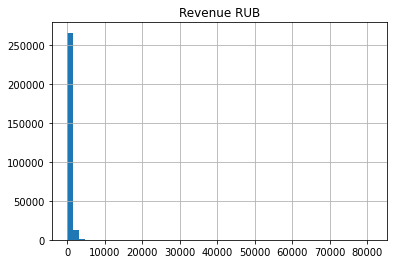

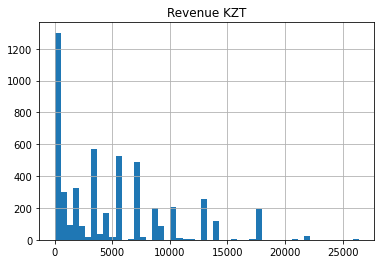

In [26]:
#Гистограммы

df_rub['revenue'].hist(bins=50)
plt.title('Revenue RUB')
plt.show()

df_kzt['revenue'].hist(bins=50)
plt.title('Revenue KZT')
plt.show()

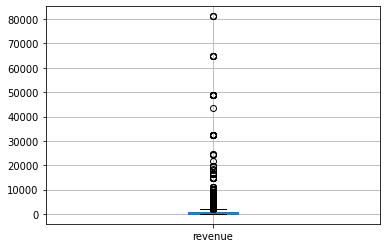

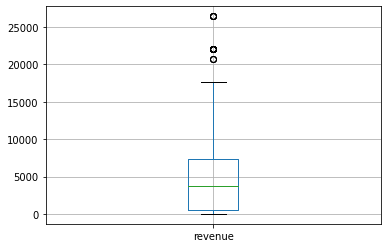

In [27]:
#Боксплот

df_rub.boxplot(column='revenue')
plt.show()

df_kzt.boxplot(column='revenue')
plt.show()

In [28]:
#Выбросы
p99_rub = df_rub['revenue'].quantile(0.99)
p99_kzt = df_kzt['revenue'].quantile(0.99)

p99_rub, p99_kzt

(2574.320068359375, 17617.240234375)

In [29]:
#Фильтруем
df_rub_clean = df_rub[df_rub['revenue'] <= p99_rub]
df_kzt_clean = df_kzt[df_kzt['revenue'] <= p99_kzt]

#Объединяем обратно
df_clean = pd.concat([df_rub_clean, df_kzt_clean])

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 281879 entries, 0 to 290727
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                281879 non-null  int64         
 1   user_id                 281879 non-null  object        
 2   created_dt_msk          281879 non-null  datetime64[ns]
 3   created_ts_msk          281879 non-null  datetime64[ns]
 4   event_id                281879 non-null  int64         
 5   cinema_circuit          281879 non-null  object        
 6   age_limit               281879 non-null  float32       
 7   currency_code           281879 non-null  object        
 8   device_type_canonical   281879 non-null  object        
 9   revenue                 281879 non-null  float32       
 10  service_name            281879 non-null  object        
 11  tickets_count           281879 non-null  float32       
 12  total                   281879

In [30]:
df_clean[['revenue', 'tickets_count']].describe()

,revenue,tickets_count
count,281879.000000,281879.000000
mean,599.911133,2.743862
std,991.924805,1.156606
min,0.020000,1.000000
25%,125.669998,2.000000
50%,362.380005,3.000000
75%,805.479980,3.000000
max,17617.240234,47.000000


In [31]:
df = df_clean

In [32]:
#Проверка дубликатов
#Полные дублиткаты
df.duplicated().sum()

0

In [33]:
#Неявные дубликаты

#Берем все, что описывает покупки
key_cols = [
    'user_id',
    'event_id',
    'created_dt_msk',
    'tickets_count',
    'revenue',
    'device_type_canonical',
    'currency_code'
]

In [34]:
#Кол-во неявных дубликатов
df.duplicated(subset=key_cols).sum()

49574

In [35]:
#Проверка
df[df.duplicated(subset=key_cols, keep=False)].sort_values(key_cols)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,rate
11,6818249,000cf0659a9f40f,2024-06-20,2024-06-20 10:49:48,516728,нет,12.0,rub,mobile,710.950012,...,концерты,№1756,Широковская область,Радужнополье,35.0,4471.0,"Киновидеостудия ""Тон"" и партнеры","ул. Тихая, д. 69 стр. 669",2024-06-20,0.180419
16,6818104,000cf0659a9f40f,2024-06-20,2024-06-20 12:46:11,516728,нет,12.0,rub,mobile,710.950012,...,концерты,№1756,Широковская область,Радужнополье,35.0,4471.0,"Киновидеостудия ""Тон"" и партнеры","ул. Тихая, д. 69 стр. 669",2024-06-20,0.180419
9,6818017,000cf0659a9f40f,2024-06-20,2024-06-20 10:35:26,516728,нет,12.0,rub,mobile,1421.910034,...,концерты,№1756,Широковская область,Радужнополье,35.0,4471.0,"Киновидеостудия ""Тон"" и партнеры","ул. Тихая, д. 69 стр. 669",2024-06-20,0.180419
12,6818220,000cf0659a9f40f,2024-06-20,2024-06-20 10:56:16,516728,нет,12.0,rub,mobile,1421.910034,...,концерты,№1756,Широковская область,Радужнополье,35.0,4471.0,"Киновидеостудия ""Тон"" и партнеры","ул. Тихая, д. 69 стр. 669",2024-06-20,0.180419
13,6818075,000cf0659a9f40f,2024-06-20,2024-06-20 12:42:12,516728,нет,12.0,rub,mobile,1421.910034,...,концерты,№1756,Широковская область,Радужнополье,35.0,4471.0,"Киновидеостудия ""Тон"" и партнеры","ул. Тихая, д. 69 стр. 669",2024-06-20,0.180419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290816,3260210,fffcd3dde79eb2c,2024-08-04,2024-08-04 11:29:36,554265,нет,0.0,rub,mobile,213.809998,...,спорт,№1550,Каменевский регион,Глиногорск,213.0,1616.0,"Центр по изучению культуры ""Огни"" Групп","бул. Большой, д. 5/7 стр. 1",2024-08-04,0.180536
290817,3260036,fffcd3dde79eb2c,2024-08-04,2024-08-04 11:16:39,554265,нет,0.0,rub,mobile,213.809998,...,спорт,№1550,Каменевский регион,Глиногорск,213.0,1616.0,"Центр по изучению культуры ""Огни"" Групп","бул. Большой, д. 5/7 стр. 1",2024-08-04,0.180536
290818,3260181,fffcd3dde79eb2c,2024-08-04,2024-08-04 11:12:41,554265,нет,0.0,rub,mobile,213.809998,...,спорт,№1550,Каменевский регион,Глиногорск,213.0,1616.0,"Центр по изучению культуры ""Огни"" Групп","бул. Большой, д. 5/7 стр. 1",2024-08-04,0.180536
290819,3260007,fffcd3dde79eb2c,2024-08-04,2024-08-04 11:25:14,554265,нет,0.0,rub,mobile,213.809998,...,спорт,№1550,Каменевский регион,Глиногорск,213.0,1616.0,"Центр по изучению культуры ""Огни"" Групп","бул. Большой, д. 5/7 стр. 1",2024-08-04,0.180536


In [36]:
#Удаляем неявные дубликаты 
df = df.drop_duplicates(subset=key_cols)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 232305 entries, 0 to 290726
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                232305 non-null  int64         
 1   user_id                 232305 non-null  object        
 2   created_dt_msk          232305 non-null  datetime64[ns]
 3   created_ts_msk          232305 non-null  datetime64[ns]
 4   event_id                232305 non-null  int64         
 5   cinema_circuit          232305 non-null  object        
 6   age_limit               232305 non-null  float32       
 7   currency_code           232305 non-null  object        
 8   device_type_canonical   232305 non-null  object        
 9   revenue                 232305 non-null  float32       
 10  service_name            232305 non-null  object        
 11  tickets_count           232305 non-null  float32       
 12  total                   232305

In [38]:
#Создаем 'revenue_rub'
df = df.copy()

df['revenue_rub'] = df['revenue']

mask_kzt = df['currency_code'] == 'kzt'

df.loc[mask_kzt, 'revenue_rub'] = (
    df.loc[mask_kzt, 'revenue'] * df.loc[mask_kzt, 'rate']
)

In [39]:
#Создаем 'one_ticket_revenue_rub'
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']

In [40]:
#Создаем 'month'
df['month'] = df['created_dt_msk'].dt.month

In [41]:
#Создаем 'season'
def get_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    else:
        return 'осень'

df['season'] = df['month'].apply(get_season)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 232305 entries, 0 to 290726
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                232305 non-null  int64         
 1   user_id                 232305 non-null  object        
 2   created_dt_msk          232305 non-null  datetime64[ns]
 3   created_ts_msk          232305 non-null  datetime64[ns]
 4   event_id                232305 non-null  int64         
 5   cinema_circuit          232305 non-null  object        
 6   age_limit               232305 non-null  float32       
 7   currency_code           232305 non-null  object        
 8   device_type_canonical   232305 non-null  object        
 9   revenue                 232305 non-null  float32       
 10  service_name            232305 non-null  object        
 11  tickets_count           232305 non-null  float32       
 12  total                   232305

In [43]:
#Датафрейми после очистки
n_after = len(df)

print(f'Кол-во строк до очистки: {n_before}. Кол-во строк после очистки: {n_after}.')

Кол-во строк до очистки: 290849. Кол-во строк после очистки: 232305.


In [44]:
#Проверяем потерю данных
loss = n_before - n_after
loss_pct = loss / n_before * 100

print(f'Потеря данных в количестве {loss} строк или {loss_pct}%')

Потеря данных в количестве 58544 строк или 20.12865782588216%


**Промежуточный вывод:**

1. Были загружены и объеденены данные из 3х датасетов /datasets/rest_info.csv и /datasets/rest_price.csv. Объендененный датасет содержал 26 столбцов и 290849 строк
2. Для оптимизации работы с данными в датафрейме были произведены следующие изменения типов данных:
  - 'created_dt_msk', 'created_ts_msk' и 'date' тип данных изменён с object на datetime.
  - Проведена оптимизация чисел для столбцов 'age_limit', 'revenue', 'tickets_count', 'rate'.
3. Проведен анализ пропусков. Обнаруженные пропуски (238 значений) в полях, связанных с информацией о событиях, были удалены.
4. Проведен анализ явных и неявных дубликатов, явные и неявные дубликаты удалены. 
5. Обработаны выбросы: 
 - Для столбца revenue применена фильтрация по 99-му процентилю
 - Отдельно обработаны данные по разным валютам (RUB и KZT)
6. Были созданы новые столбцы:
  - revenue_rub — выручка, приведённая к рублю с использованием курса тенге 
  - one_ticket_revenue_rub — средняя выручка на один билет 
  - month — месяц оформления заказа 
  - season — сезон оформления заказа (зима/весна/лето/осень) 
7. После предобработки: исходное количество записей - 290849, итоговое количество записей - 232305, доля удалённых данных - 20.1%.

## Исследовательский анализ данных

### Анализ распределения заказов по сегментам и их сезонные изменения

In [45]:
#Считаем заказы по месяцам
monthly_orders = df.groupby('month')['order_id'].count().sort_index()
monthly_orders

month
6     28266
7     32471
8     36679
9     56121
10    78768
Name: order_id, dtype: int64

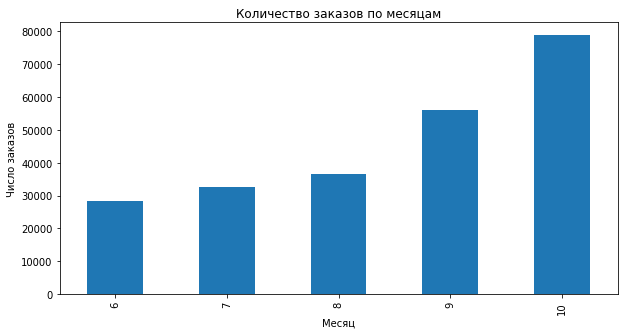

In [46]:
#Визуализация
monthly_orders.plot(kind='bar', figsize=(10,5))
plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Число заказов')
plt.show()

- Спрос растет от июня к октябрю. Летом активность ниже, чем осенью.

In [47]:
#Создаем фильтр по времени года
summer = df[df['season'] == 'лето']
autumn = df[df['season'] == 'осень']

In [48]:
#Сравнение сегментов

#Мероприятия
summer_event = summer['event_type_main'].value_counts(normalize=True)
autumn_event = autumn['event_type_main'].value_counts(normalize=True)

event_cmp = pd.concat([summer_event, autumn_event], axis=1)
event_cmp.columns = ['summer', 'autumn']
event_cmp

,summer,autumn
концерты,0.442935,0.388386
другое,0.251540,0.203968
театр,0.203006,0.257923
стендап,0.056982,0.044214
выставки,0.021978,0.015516
спорт,0.021116,0.079666
ёлки,0.002443,0.010327


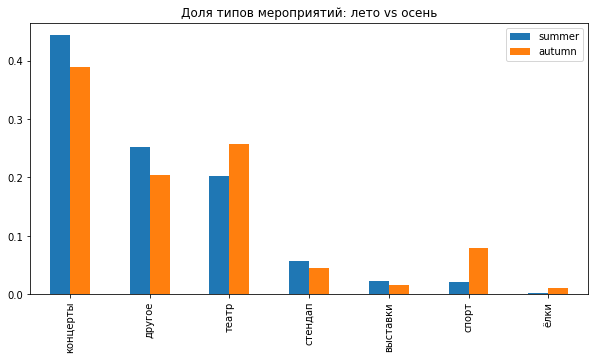

In [49]:
event_cmp.plot(kind='bar', figsize=(10,5))
plt.title('Доля типов мероприятий: лето vs осень')
plt.show()

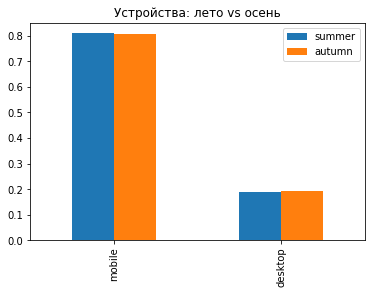

In [50]:
#Устройства
summer_device = summer['device_type_canonical'].value_counts(normalize=True)
autumn_device = autumn['device_type_canonical'].value_counts(normalize=True)

device_cmp = pd.concat([summer_device, autumn_device], axis=1)
device_cmp.columns = ['summer', 'autumn']

device_cmp.plot(kind='bar')
plt.title('Устройства: лето vs осень')
plt.show()

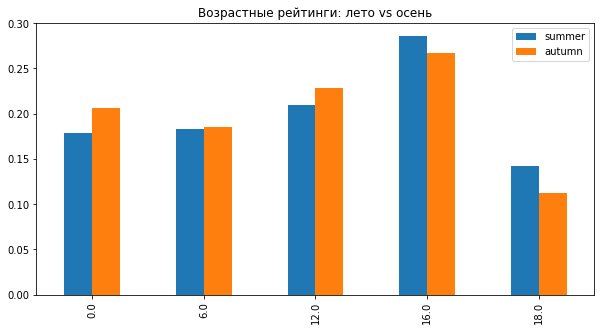

In [51]:
#Возрастной рейтинг
summer_age = summer['age_limit'].value_counts(normalize=True)
autumn_age = autumn['age_limit'].value_counts(normalize=True)

age_cmp = pd.concat([summer_age, autumn_age], axis=1)
age_cmp.columns = ['summer', 'autumn']

age_cmp.plot(kind='bar', figsize=(10,5))
plt.title('Возрастные рейтинги: лето vs осень')
plt.show()

In [52]:
#Средняя выручка за билет 

summer_rev = summer.groupby('event_type_main')['one_ticket_revenue_rub'].mean()
autumn_rev = autumn.groupby('event_type_main')['one_ticket_revenue_rub'].mean()

rev_cmp = pd.concat([summer_rev, autumn_rev], axis=1)
rev_cmp.columns = ['summer', 'autumn']
rev_cmp

,summer,autumn
event_type_main,,
выставки,86.853630,90.919479
другое,87.691383,79.183289
концерты,302.786591,271.434509
спорт,61.439640,56.198238
стендап,217.101837,231.403275
театр,216.006256,176.295425
ёлки,274.258484,232.028671


In [53]:
rev_cmp['change_%'] = (rev_cmp['autumn'] - rev_cmp['summer']) / rev_cmp['summer'] * 100
rev_cmp.sort_values('change_%', ascending=False)

,summer,autumn,change_%
event_type_main,,,
стендап,217.101837,231.403275,6.587432
выставки,86.853630,90.919479,4.681266
спорт,61.439640,56.198238,-8.530977
другое,87.691383,79.183289,-9.702316
концерты,302.786591,271.434509,-10.354514
ёлки,274.258484,232.028671,-15.397814
театр,216.006256,176.295425,-18.384111


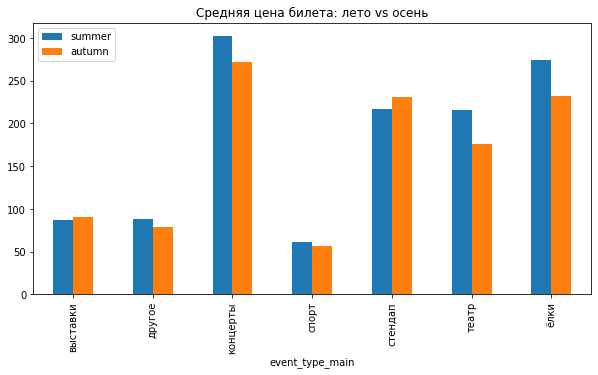

In [54]:
rev_cmp[['summer','autumn']].plot(kind='bar', figsize=(10,5))
plt.title('Средняя цена билета: лето vs осень')
plt.show()

**Вывод:**
1. Спрос растет от июня к октябрю. Летом активность ниже, чем осенью. Это может быть обусловлено: возвращением аудитории после лета, ростом кол-ва культурных мероприятий, новым сезоном театров/концертов.
2. Осенью более востребованы театры, спорт и елки. В то время летом более востребованы концерты, стендапы и выставки.
3. Явной разницы по устройствам между летом и осенью нет.
4. По возрастному рейтингу летом доля 16+ и 18+ выше, что говорит о смещении в сторону взрослой аудитории, что может быть связано с меньшем кол-вом семейных активностей. Осенью доля 0+, 6+ и 12+ выше, что может быть связано с возвращением семей с отпусков, началом школьного сезона, что меняет структуру спроса. 
5. В летний период более высокая средняя цена билета наблюдается для концертов и театральных постановок, что может быть связано с преобладанием масштабных мероприятий (например, open-air и гастрольных событий). В осенний период рост средней стоимости характерен для стендапов и выставок, что может отражать увеличение спроса и изменение структуры предложения в сторону более регулярных и востребованных форматов досуга.

### Осенняя активность пользователей

In [55]:
#Осень
df_autumn = df[df['season'] == 'осень'].copy()

In [56]:
#Подсчет метрик
daily = df_autumn.groupby('created_dt_msk').agg(
    orders=('order_id', 'count'),
    dau=('user_id', 'nunique'),
    revenue=('revenue_rub', 'sum'),
    tickets=('tickets_count', 'sum')
).reset_index()

daily['orders_per_user'] = daily['orders'] / daily['dau']
daily['avg_ticket_price'] = daily['revenue'] / daily['tickets']

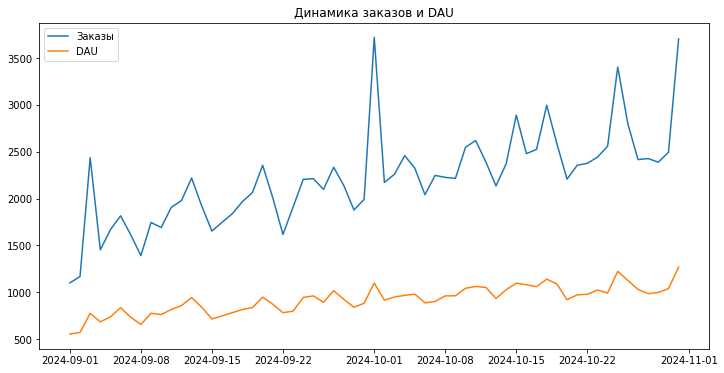

In [57]:
#Визуализация

plt.figure(figsize=(12,6))
plt.plot(daily['created_dt_msk'], daily['orders'], label='Заказы')
plt.plot(daily['created_dt_msk'], daily['dau'], label='DAU')
plt.legend()
plt.title('Динамика заказов и DAU')
plt.show()

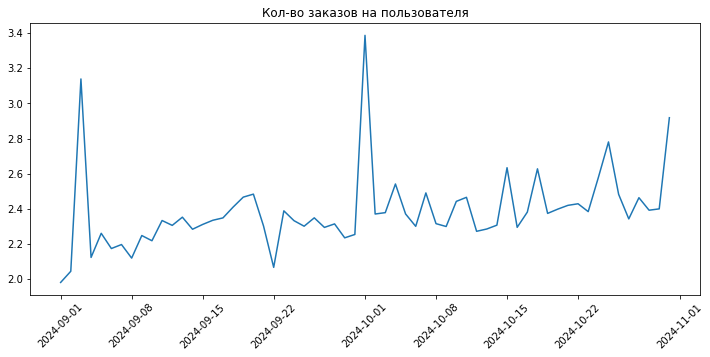

In [58]:
plt.figure(figsize=(12,5))
plt.plot(daily['created_dt_msk'], daily['orders_per_user'])
plt.title('Кол-во заказов на пользователя')
plt.xticks(rotation=45)
plt.show()

- Пиковые повышения кол-ва заказов на пользователя в начале месяца
- Плавное повышение заказов на пользователя к концу октября

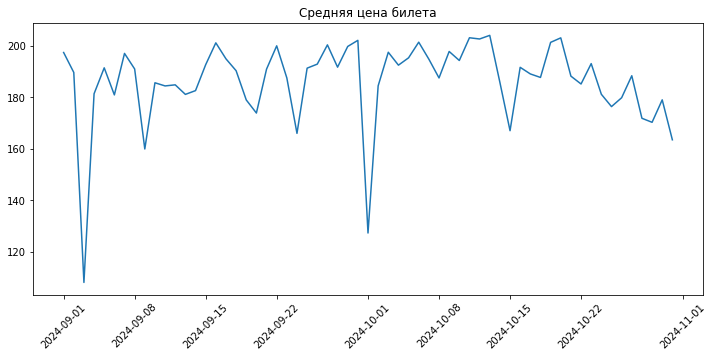

In [59]:
plt.figure(figsize=(12,5))
plt.plot(daily['created_dt_msk'], daily['avg_ticket_price'])
plt.title('Средняя цена билета')
plt.xticks(rotation=45)
plt.show()

- Пиковое снижение средней цены билета в начале месяца

In [60]:
#Недельная цикличность
daily['weekday'] = daily['created_dt_msk'].dt.dayofweek

#Агрегируем
weekly = daily.groupby('weekday').agg(
    orders=('orders', 'mean'),
    dau=('dau', 'mean'),
    orders_per_user=('orders_per_user', 'mean'),
    avg_ticket_price=('avg_ticket_price', 'mean')
)
weekly

,orders,dau,orders_per_user,avg_ticket_price
weekday,,,,
0,1995.444444,851.555556,2.328554,186.811142
1,2418.666667,933.000000,2.577874,165.812439
2,2149.000000,922.222222,2.324726,188.185333
3,2378.444444,960.000000,2.454001,185.993286
4,2525.125000,1017.000000,2.465530,187.030884
5,2222.000000,952.125000,2.325223,192.705383
6,1826.444444,813.333333,2.227437,197.547470


In [61]:
weekday_map = {
    0:'Пн',1:'Вт',2:'Ср',3:'Чт',4:'Пт',5:'Сб',6:'Вс'
}

weekly.index = weekly.index.map(weekday_map)
weekly

,orders,dau,orders_per_user,avg_ticket_price
weekday,,,,
Пн,1995.444444,851.555556,2.328554,186.811142
Вт,2418.666667,933.000000,2.577874,165.812439
Ср,2149.000000,922.222222,2.324726,188.185333
Чт,2378.444444,960.000000,2.454001,185.993286
Пт,2525.125000,1017.000000,2.465530,187.030884
Сб,2222.000000,952.125000,2.325223,192.705383
Вс,1826.444444,813.333333,2.227437,197.547470


**Вывод:**
- Пик активности: Пт — максимум заказов и пользователей
- Пользователи покупают ДО выходных: в Пт - планирование досуга, в Чт–Пт - принятие решений о покупке 
- Минимум в Вс, что говорит о том, что люди уже сходили на мероприятия и нет необходимости покупать
- orders_per_user почти стабильный - рост заказов идёт за счёт DAU, а не за счёт того, что пользователи покупают больше. Пик во Вт (2.57), возможные причины: акции/рассылки.
- Средний чек растет к выходным: максимум - Вс (197.5), минимум - вторник (165.8), что также может указывать на акции во Вт.
- В начале месяца наблюдаются пики по количеству заказов на пользователя, а к концу октября этот показатель постепенно растёт. Это говорит о том, что пользователи начинают чаще совершать покупки к концу осени/началу зимы.
- При этом в начале месяца заметно снижение средней цены билета. Вероятно, в этот период увеличивается доля более дешёвых мероприятий.

### Популярные события и партнёры

In [62]:
#Анализ по регионам

#Агрегируем
region_stats = df.groupby('region_name').agg(
    unique_events=('event_id', 'nunique'),
    orders=('order_id', 'count')
).reset_index()

In [63]:
#Доли
region_stats['events_share'] = region_stats['unique_events'] / region_stats['unique_events'].sum()
region_stats['orders_share'] = region_stats['orders'] / region_stats['orders'].sum()

In [64]:
#Сортировка
region_stats = region_stats.sort_values('orders', ascending=False)
region_stats.head(10)

,region_name,unique_events,orders,events_share,orders_share
23,Каменевский регион,5793,72078,0.263222,0.310273
60,Североярская область,3777,37591,0.171619,0.161817
77,Широковская область,1217,13640,0.055298,0.058716
45,Озернинский край,349,8673,0.015858,0.037335
42,Медовская область,462,6717,0.020992,0.028915
57,Светополянский округ,1059,6304,0.048119,0.027137
41,Малиновоярский округ,165,5394,0.007497,0.023219
52,Речиновская область,701,5249,0.031852,0.022595
78,Яблоневская область,534,5125,0.024264,0.022062
61,Серебринская область,541,4663,0.024582,0.020073


In [65]:
#Анализ партнеров

#Агрегируем
partner_stats = df.groupby('service_name').agg(
    unique_events=('event_id', 'nunique'),
    orders=('order_id', 'count'),
    revenue=('revenue_rub', 'sum')
).reset_index()

In [66]:
#Доли
partner_stats['orders_share'] = partner_stats['orders'] / partner_stats['orders'].sum()
partner_stats['revenue_share'] = partner_stats['revenue'] / partner_stats['revenue'].sum()

In [67]:
#Сортировка
partner_stats = partner_stats.sort_values('revenue', ascending=False)
partner_stats.head(10)

,service_name,unique_events,orders,revenue,orders_share,revenue_share
3,Билеты без проблем,4018,49265,21161216.0,0.212070,0.168859
24,Мой билет,1296,28292,17869328.0,0.121788,0.142591
25,Облачко,2335,23132,16163013.0,0.099576,0.128975
8,Весь в билетах,856,14069,14178810.0,0.060563,0.113142
21,Лови билет!,4812,33449,13625664.0,0.143987,0.108728
5,Билеты в руки,3483,29103,10711953.0,0.125279,0.085478
19,Край билетов,252,5089,5360970.5,0.021907,0.042779
26,Прачечная,1025,7921,3698724.0,0.034097,0.029515
13,Дом культуры,271,3581,3555980.0,0.015415,0.028376
35,Яблоко,714,4076,3175536.5,0.017546,0.025340


**Вывод:**
- По регионам:
    - Явный лидер - Каменевский регион: 31% всех заказов, 26% всех мероприятий
    - Североярская область: 16% заказов, 17% мероприятий - сбалансированный регион — спрос = предложение
    - Топ-2 региона дают примерно 47% заказов - умеренная концентрация
- По партнерам:
    - Лидеры рынка - "Билеты без проблем": 21% заказов, 16.9% выручки - лидер по объёму, но средний чек ниже рынка
    - "Лови билет!": 14.4% заказов, 10.8% выручки - массовый сегмент (много заказов, ниже чек)
    - Лидеры по выручке (ключевой инсайт)
    - "Мой билет": 12% заказов, 14.3% выручки; "Облачко": 10% заказов, 12.9% выручки; "Весь в билетах": 6% заказов, 11.3% выручки - продают более дорогие билеты (премиум или качественный ассортимент)
    - Топ-5 партнёров дают примерно 66%+ выручки - рынок сильно сконцентрирован.

## Статистический анализ данных

In [68]:
df_fall = df[df['season'] == 'осень'].copy()

### Гипотеза 1

**Формулировка гипотезы**
- H0 (нулевая): среднее количество заказов на пользователя мобильных устройств меньше или равно, чем у пользователей стационарных устройств
- H1 (альтернативная): среднее количество заказов на пользователя мобильных устройств больше, чем у пользователей стационарных устройств

In [69]:
#Заказы на пользователя
orders_per_user = (
    df_fall.groupby(['user_id', 'device_type_canonical'])['order_id']
    .nunique()
    .reset_index(name='orders_cnt')
)

In [70]:
#Кол-во типов устройств у пользователя
user_device_count = (
    orders_per_user.groupby('user_id')['device_type_canonical']
    .nunique()
)

#Пользователи с одним устройством
single_users = user_device_count[user_device_count == 1].index

#Пользователи с двумя устройствами
multi_users = user_device_count[user_device_count > 1].index

In [71]:
#Независимые выборки
single_data = orders_per_user[
    orders_per_user['user_id'].isin(single_users)
]

mobile_single = single_data[
    single_data['device_type_canonical'] == 'mobile'
]['orders_cnt']

desktop_single = single_data[
    single_data['device_type_canonical'] == 'desktop'
]['orders_cnt']

In [72]:
print('Mobile (single users)')
print(mobile_single.describe())

print('\nDesktop (single users)')
print(desktop_single.describe())

Mobile (single users)
count    10875.000000
mean         2.368368
std          2.932198
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max         87.000000
Name: orders_cnt, dtype: float64

Desktop (single users)
count    1627.000000
mean        1.575907
std         1.509986
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        30.000000
Name: orders_cnt, dtype: float64


In [73]:
mobile_single.quantile([0.9, 0.95, 0.99])

0.90     5.0
0.95     7.0
0.99    14.0
Name: orders_cnt, dtype: float64

In [74]:
#Проверка среднего
q99 = mobile_single.quantile(0.99)
mobile_trimmed = mobile_single[mobile_single <= q99]

mobile_trimmed.mean()

2.190206807011036

In [75]:
desktop_single.quantile([0.9, 0.95, 0.99])

0.90    3.0
0.95    3.0
0.99    6.0
Name: orders_cnt, dtype: float64

In [76]:
#Проверка среднего
q99 = desktop_single.quantile(0.99)
desktop_trimmed = desktop_single[desktop_single <= q99]

desktop_trimmed.mean()

1.4758064516129032

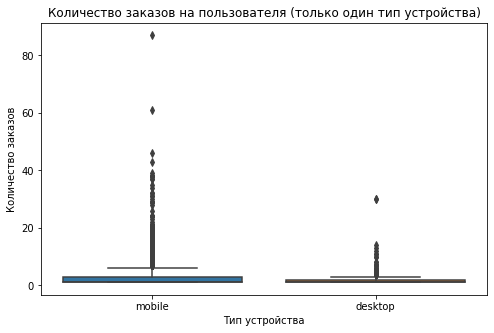

In [77]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=single_data,
    x='device_type_canonical',
    y='orders_cnt'
)

plt.title('Количество заказов на пользователя (только один тип устройства)')
plt.xlabel('Тип устройства')
plt.ylabel('Количество заказов')

plt.show()

In [78]:
#Проводим тест 
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    mobile_single,
    desktop_single,
    alternative='greater'
)

print(f'p_value (single users) = {p_value}')

alpha = 0.05

if p_value < alpha:
    print('Отклоняем H0: mobile > desktop (для пользователей с одним устройством)')
else:
    print('Нет оснований отклонить H0 (для пользователей с одним устройством)')

p_value (single users) = 3.9150275180076214e-45
Отклоняем H0: mobile > desktop (для пользователей с одним устройством)


In [79]:
#Зависимые выборки
multi_data = orders_per_user[
    orders_per_user['user_id'].isin(multi_users)
]

pivot_multi = multi_data.pivot(
    index='user_id',
    columns='device_type_canonical',
    values='orders_cnt'
).dropna()

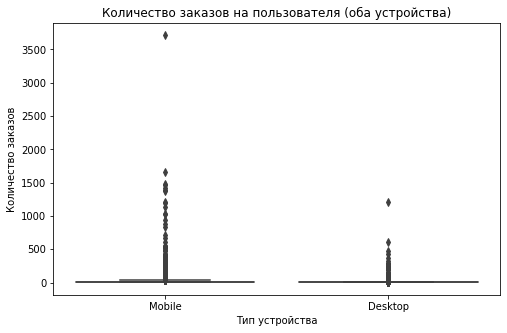

In [80]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=pivot_multi[['mobile', 'desktop']])

plt.title('Количество заказов на пользователя (оба устройства)')
plt.xlabel('Тип устройства')
plt.ylabel('Количество заказов')

plt.xticks([0, 1], ['Mobile', 'Desktop'])

plt.show()

In [81]:
#Проводим тест 
from scipy.stats import wilcoxon

stat, p_value = wilcoxon(
    pivot_multi['mobile'],
    pivot_multi['desktop'],
    alternative='greater'
)

print(f'p_value (multi users) = {p_value}')

if p_value < alpha:
    print('Отклоняем H0: mobile > desktop (для пользователей с двумя устройствами)')
else:
    print('Нет оснований отклонить H0 (для пользователей с двумя устройствами)')

p_value (multi users) = 0.0
Отклоняем H0: mobile > desktop (для пользователей с двумя устройствами)


**Вывод по гипотизе 1:**
- Пользователи были разделены на две группы: использующие только один тип устройства и использующие оба типа устройств. Распределения количества заказов на пользователя в обеих группах имеют сильную правостороннюю асимметрию и содержат выбросы.
  - Для пользователей с одним устройством выборки являются независимыми, поэтому был применён критерий Манна–Уитни.
  - Для пользователей, использующих оба устройства, наблюдения являются зависимыми, поэтому был применён парный критерий Уилкоксона.
- В обоих случаях получены крайне малые значения p-value (значительно ниже уровня значимости 0.05), что позволяет отвергнуть нулевую гипотезу H0. Таким образом, есть статистически значимые основания утверждать, что:
   - пользователи мобильных устройств в среднем совершают больше заказов, чем пользователи стационарных устройств.

### Гипотеза 2

**Формулировка гипотезы**
- H0: среднее время между заказами у мобильных пользователей меньше или равно, чем у пользователей стационарных устройств
- H1: среднее время между заказами у мобильных пользователей больше, чем у пользователей стационарных устройств

In [82]:
df_days = df_fall[df_fall['days_since_prev'].notna()]

In [83]:
#Разделяем на группы
user_device_type = df_days.groupby('user_id')['device_type_canonical'].nunique()

single_users = user_device_type[user_device_type == 1].index
multi_users = user_device_type[user_device_type > 1].index


In [84]:
#Только одно устройство 
single_data = df_days[df_days['user_id'].isin(single_users)]

mobile_only = single_data[
    single_data['device_type_canonical'] == 'mobile'
]['days_since_prev']

desktop_only = single_data[
    single_data['device_type_canonical'] == 'desktop'
]['days_since_prev']

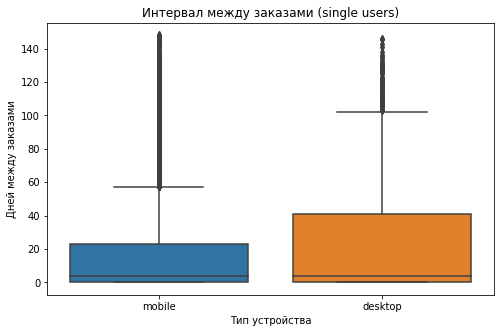

In [85]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=single_data,
    x='device_type_canonical',
    y='days_since_prev'
)

plt.title('Интервал между заказами (single users)')
plt.xlabel('Тип устройства')
plt.ylabel('Дней между заказами')

plt.show()

In [86]:
#Оба устройства
multi_data = df_days[df_days['user_id'].isin(multi_users)]

pivot_multi = multi_data.pivot_table(
    index=['user_id', 'device_type_canonical'],
    values='days_since_prev',
    aggfunc='mean'
).reset_index()

mobile_multi = pivot_multi[pivot_multi['device_type_canonical'] == 'mobile']['days_since_prev']
desktop_multi = pivot_multi[pivot_multi['device_type_canonical'] == 'desktop']['days_since_prev']

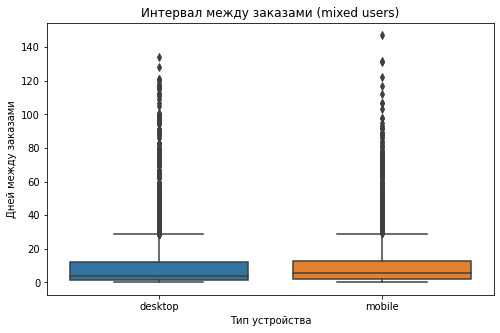

In [87]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=pivot_multi,
    x='device_type_canonical',
    y='days_since_prev'
)

plt.title('Интервал между заказами (mixed users)')
plt.xlabel('Тип устройства')
plt.ylabel('Дней между заказами')

plt.show()

In [88]:
#Проверка
mobile_only.describe()

count    19338.000000
mean        17.535061
std         27.751197
min          0.000000
25%          0.000000
50%          4.000000
75%         23.000000
max        148.000000
Name: days_since_prev, dtype: float64

In [89]:
mobile_only.quantile([0.9, 0.95, 0.99])

0.90     59.0
0.95     84.0
0.99    120.0
Name: days_since_prev, dtype: float64

In [90]:
#Проверка среднего
q99 = mobile_only.quantile(0.99)
mobile_only_trimmed = mobile_only[mobile_only <= q99]

mobile_only_trimmed.mean()

16.39947767041003

In [91]:
#Проверка 
desktop_only.describe()

count    1625.000000
mean       24.530462
std        34.992317
min         0.000000
25%         0.000000
50%         4.000000
75%        41.000000
max       146.000000
Name: days_since_prev, dtype: float64

In [92]:
desktop_only.quantile([0.9, 0.95, 0.99])

0.90     82.00
0.95    101.80
0.99    129.76
Name: days_since_prev, dtype: float64

In [93]:
#Проверка среднего
q99 = desktop_only.quantile(0.99)
desktop_only_trimmed = desktop_only[desktop_only <= q99]

desktop_only_trimmed.mean()

23.351990049751244

In [94]:
#Проверка
mobile_multi.describe()

count    2994.000000
mean       11.083276
std        15.613631
min         0.000000
25%         2.294662
50%         5.500000
75%        13.000000
max       147.000000
Name: days_since_prev, dtype: float64

In [95]:
mobile_multi.quantile([0.9, 0.95, 0.99])

0.90    29.00
0.95    42.35
0.99    77.00
Name: days_since_prev, dtype: float64

In [96]:
#Проверка среднего
q99 = mobile_multi.quantile(0.99)
mobile_multi_trimmed = mobile_multi[mobile_multi <= q99]

mobile_multi_trimmed.mean()

10.237884713810253

In [97]:
#Проверка 
desktop_multi.describe()

count    2994.000000
mean       10.786257
std        17.355785
min         0.000000
25%         1.250000
50%         4.000000
75%        12.312500
max       134.000000
Name: days_since_prev, dtype: float64

In [98]:
desktop_multi.quantile([0.9, 0.95, 0.99])

0.90    29.000000
0.95    44.116667
0.99    94.070000
Name: days_since_prev, dtype: float64

In [99]:
#Проверка среднего
q99 = desktop_multi.quantile(0.99)
desktop_multi_trimmed = desktop_multi[desktop_multi <= q99]

desktop_multi_trimmed.mean()

9.800288088885615

In [100]:
#Проводим тест
from scipy.stats import mannwhitneyu

stat_single, p_single = mannwhitneyu(
    mobile_only,
    desktop_only,
    alternative='greater'
)

print('Single users p-value:', p_single)

alpha = 0.05

print("Single users:")
if p_single < alpha:
    print("Отклоняем H0: mobile > desktop (интервал больше)")
else:
    print("Нет оснований отклонить H0")

Single users p-value: 0.8299130689271246
Single users:
Нет оснований отклонить H0


In [101]:
from scipy.stats import wilcoxon

stat_multi, p_multi = wilcoxon(
    mobile_multi,
    desktop_multi,
    alternative='greater'
)

print('Mixed users p-value:', p_multi)

alpha = 0.05

print("Mixed users:")
if p_multi < alpha:
    print("Отклоняем H0: mobile > desktop (интервал больше)")
else:
    print("Нет оснований отклонить H0")

Mixed users p-value: 8.57630980395374e-09
Mixed users:
Отклоняем H0: mobile > desktop (интервал больше)


**Вывод по гипотизе 2:**
- Пользователи были разделены на две группы: использующие только один тип устройства и использующие оба типа устройств. Распределения времени между заказами в обеих группах имеют выраженную правостороннюю асимметрию и содержат выбросы.
  - Для пользователей с одним устройством выборки являются независимыми, поэтому был применён критерий Манна–Уитни. 
  - Для пользователей, использующих оба устройства, наблюдения являются зависимыми, поэтому был применён парный критерий Уилкоксона.
- По результатам тестов получены разные выводы: в группе пользователей с одним устройством статистически значимых различий не выявлено (p-value > 0.05), в то время как в группе пользователей с двумя устройствами получено крайне малое значение p-value (значительно ниже 0.05), что позволяет отвергнуть нулевую гипотезу H0.
- Таким образом, можно утверждать, что у пользователей, использующих оба типа устройств, интервал между заказами на мобильных устройствах статистически значимо больше, чем на стационарных устройствах, тогда как для пользователей с одним устройством различий не обнаружено.

**Итоговый вывод по гипотезам:**
- Пользователи были разделены на две группы: использующие только один тип устройства и использующие оба типа устройств. В обеих гипотезах рассматривались разные метрики — количество заказов на пользователя и время между заказами. Распределения в данных имеют выраженную правостороннюю асимметрию и содержат выбросы, поэтому для анализа использовались непараметрические методы.
  - Для пользователей с одним устройством выборки являются независимыми, поэтому применялся критерий Манна–Уитни. 
  - Для пользователей, использующих оба устройства, наблюдения являются зависимыми, поэтому применялся парный критерий Уилкоксона.
- Результаты показали, что:
  - по количеству заказов статистически значимые различия между мобильными и стационарными пользователями наблюдаются в обеих группах (p-value < 0.05), что позволяет утверждать, что пользователи мобильных устройств совершают больше заказов;
  - по времени между заказами различия зависят от типа пользователей: у пользователей с одним устройством статистически значимых различий не выявлено, тогда как у пользователей, использующих оба типа устройств, мобильные пользователи имеют статистически значимо больший интервал между заказами.
- Таким образом, мобильные пользователи проявляют более высокую активность по количеству заказов, однако их поведение по частоте покупок неоднородно: значимые различия во времени между заказами наблюдаются только среди пользователей, использующих оба типа устройств.

## Общий вывод и рекомендации

**Проведена предобработка данных и подготовка их к исследованию**
1. Были загружены и объеденены данные из 3х датасетов /datasets/rest_info.csv и /datasets/rest_price.csv. Объендененный датасет содержал 26 столбцов и 290849 строк
2. Для оптимизации работы с данными в датафрейме были произведены следующие изменения типов данных:
  - 'created_dt_msk', 'created_ts_msk' и 'date' тип данных изменён с object на datetime.
  - Проведена оптимизация чисел для столбцов 'age_limit', 'revenue', 'tickets_count', 'rate'.
3. Проведен анализ пропусков. Обнаруженные пропуски (238 значений) в полях, связанных с информацией о событиях, были удалены.
4. Проведен анализ явных и неявных дубликатов, явные и неявные дубликаты удалены. 
5. Обработаны выбросы: 
 - Для столбца revenue применена фильтрация по 99-му процентилю
 - Отдельно обработаны данные по разным валютам (RUB и KZT)
6. Были созданы новые столбцы:
  - revenue_rub — выручка, приведённая к рублю с использованием курса тенге 
  - one_ticket_revenue_rub — средняя выручка на один билет 
  - month — месяц оформления заказа 
  - season — сезон оформления заказа (зима/весна/лето/осень) 
7. После предобработки: исходное количество записей - 290849, итоговое количество записей - 232305, доля удалённых данных - 20.1%.

**Проведен исследовательский анализ данных**

1. Анализ распределения заказов по сегментам и их сезонные изменения
  1. Спрос растет от июня к октябрю. Летом активность ниже, чем осенью. Это может быть обусловлено: возвращением аудитории после лета, ростом кол-ва культурных мероприятий, новым сезоном театров/концертов.
  2. Осенью более востребованы театры, спорт и елки. В то время летом более востребованы концерты, стендапы и выставки.
  3. Явной разницы по устройствам между летом и осенью нет.
  4. По возрастному рейтингу летом доля 16+ и 18+ выше, что говорит о смещении в сторону взрослой аудитории, что может быть связано с меньшем кол-вом семейных активностей. Осенью доля 0+, 6+ и 12+ выше, что может быть связано с возвращением семей с отпусков, началом школьного сезона, что меняет структуру спроса. 
  5. В летний период более высокая средняя цена билета наблюдается для концертов и театральных постановок, что может быть связано с преобладанием масштабных мероприятий (например, open-air и гастрольных событий). В осенний период рост средней стоимости характерен для стендапов и выставок, что может отражать увеличение спроса и изменение структуры предложения в сторону более регулярных и востребованных форматов досуга.
  
  
2. Осенняя активность пользователей
  - Пик активности: Пт — максимум заказов и пользователей
  - Пользователи покупают ДО выходных: в Пт - планирование досуга, в Чт–Пт - принятие решений о покупке 
  - Минимум в Вс, что говорит о том, что люди уже сходили на мероприятия и нет необходимости покупать
  - orders_per_user почти стабильный - рост заказов идёт за счёт DAU, а не за счёт того, что пользователи покупают больше. Пик во Вт (2.57), возможные причины: акции/рассылки.
  - Средний чек растет к выходным: максимум - Вс (197.5), минимум - вторник (165.8), что также может указывать на акции во Вт.
  - В начале месяца наблюдаются пики по количеству заказов на пользователя, а к концу октября этот показатель постепенно растёт. Это говорит о том, что пользователи начинают чаще совершать покупки к концу осени/началу зимы.
  - При этом в начале месяца заметно снижение средней цены билета. Вероятно, в этот период увеличивается доля более дешёвых мероприятий.


3. Популярные события и партнёры
  - По регионам:
    - Явный лидер - Каменевский регион: 31% всех заказов, 26% всех мероприятий
    - Североярская область: 16% заказов, 17% мероприятий - сбалансированный регион — спрос = предложение
    - Топ-2 региона дают примерно 47% заказов - умеренная концентрация
  - По партнерам:
    - Лидеры рынка - "Билеты без проблем": 21% заказов, 16.9% выручки - лидер по объёму, но средний чек ниже рынка
    - "Лови билет!": 14.4% заказов, 10.8% выручки - массовый сегмент (много заказов, ниже чек)
    - Лидеры по выручке (ключевой инсайт)
    - "Мой билет": 12% заказов, 14.3% выручки; "Облачко": 10% заказов, 12.9% выручки; "Весь в билетах": 6% заказов, 11.3% выручки - продают более дорогие билеты (премиум или качественный ассортимент)
    - Топ-5 партнёров дают примерно 66%+ выручки - рынок сильно сконцентрирован.

**Проверены 2 гипотезы:**
1. Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.
2. Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

Итоговый вывод по гипотезам:
- Пользователи были разделены на две группы: использующие только один тип устройства и использующие оба типа устройств. В обеих гипотезах рассматривались разные метрики — количество заказов на пользователя и время между заказами. Распределения в данных имеют выраженную правостороннюю асимметрию и содержат выбросы, поэтому для анализа использовались непараметрические методы.
  - Для пользователей с одним устройством выборки являются независимыми, поэтому применялся критерий Манна–Уитни. 
  - Для пользователей, использующих оба устройства, наблюдения являются зависимыми, поэтому применялся парный критерий Уилкоксона.
- Результаты показали, что:
  - по количеству заказов статистически значимые различия между мобильными и стационарными пользователями наблюдаются в обеих группах (p-value < 0.05), что позволяет утверждать, что пользователи мобильных устройств совершают больше заказов;
  - по времени между заказами различия зависят от типа пользователей: у пользователей с одним устройством статистически значимых различий не выявлено, тогда как у пользователей, использующих оба типа устройств, мобильные пользователи имеют статистически значимо больший интервал между заказами.
- Таким образом, мобильные пользователи проявляют более высокую активность по количеству заказов, однако их поведение по частоте покупок неоднородно: значимые различия во времени между заказами наблюдаются только среди пользователей, использующих оба типа устройств.

**Рекомендации на основе анализа:**
1. Сезонность спроса
  1. Перераспределить маркетинговые кампании по сезонам
    - Лето: акцент на молодёжные и развлекательные события (концерты, open-air, стендапы)
    - Осень: акцент на семейные и культурные форматы (театры, детские мероприятия, спорт)
  2. Поддерживать семейный сегмент осенью
    - отдельные подборки “с детьми на выходные”
    - промо семейных пакетов
    - партнёрства с детскими и школьными активностями
  3. Использовать сезонный рост спроса
    - усиливать закупку трафика в июне–октябре
    - летом — больше акций на стимулирование возврата пользователей после отпусков


2. Поведенческая активность
  1. Фокус на удержание
    - текущая модель уже “выжала” частоту покупок
    - потенциал роста - расширение аудитории и возврат пользователей
  2. Проверить причины активности по вторникам
    - возможные акции/рассылки
    - если подтверждается - масштабировать механику
    

3. Ценовая динамика
  1. Использовать ценовые пики выходных
    - продвигать премиум-события ближе к выходным
    - запускать “пакет выходного дня”
  2. Тестировать динамическое продвижение
    - разные витрины по дням недели:
    - будни - скидочные/массовые события
    - выходные - премиум/дорогие
    
    
4. География
  1. Усиливать топ-регионы
    - локальные кампании
    - эксклюзивные мероприятия
  2. Развивать регионы с балансом спроса/предложения
    - взять регион, где система работает лучше всего, и использовать его как шаблон для развития других регионов


5. Партнёры
  1. Усиливать премиум-партнёров
    - показывать события определённых партнёров выше в списке рекомендаций или поиска
    - сделать персонализированные рекомендации пользователей
  2. Оптимизация комиссии/условий
    - массовые партнёры - эффективность и объём
    - премиум - маржинальность


6. Mobile vs desktop
  1. Не тратить ресурсы на улучшения мобильного интерфейса с целью заставить пользователей покупать чаще - это не даст эффекта на массовую аудиторию
  2. Работа с пользователями, которые пользуются продуктом сильно чаще и активнее, чем большинство остальных
    - сегментировать активных пользователей (top 1–5%)
    - программы лояльности / ранний доступ / VIP
  3. Унифицировать продуктовый опыт
    - различия между mobile/desktop не критичны
    - можно развивать как единый продукт, а не два разных поведения